# Project Description

The goal of this project is to predict the price of a car. This is a regression problem.

The dataset is a real-world car pricing data from Auto Scout for analysis and price prediction. his dataset provides comprehensive details on used car listings, including vehicle specifications, features, pricing, and more. It's valuable for analyzing car prices, trends, and customer preferences in the automotive market.

## Data Exploration

This notebook explores the data without making any permanent changes to it.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimpy import skim
import seaborn as sns

In [2]:
# Load the Data
data = '../data/external/final_scout_not_dummy.csv'
df = pd.read_csv(data)
df.head()

,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
0,Audi A1,Sedans,15770,VAT deductible,56013.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,2.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1220.0,front,3.8
1,Audi A1,Sedans,14500,Price negotiable,80000.0,Used,Benzine,7.0,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,141.0,0,Metallic,Cloth,Automatic,1798.0,1255.0,front,5.6
2,Audi A1,Sedans,14640,VAT deductible,83450.0,Used,Diesel,7.0,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
3,Audi A1,Sedans,14500,VAT deductible,73000.0,Used,Diesel,6.0,"Air suspension,Armrest,Auxiliary heating,Elect...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,0,Metallic,Cloth,Automatic,1422.0,1195.0,front,3.8
4,Audi A1,Sedans,16790,VAT deductible,16200.0,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,66.0,1,Metallic,Cloth,Automatic,1422.0,1135.0,front,4.1


In [3]:
df.head(3).T

,0,1,2
make_model,Audi A1,Audi A1,Audi A1
body_type,Sedans,Sedans,Sedans
price,15770,14500,14640
vat,VAT deductible,Price negotiable,VAT deductible
km,56013.0,80000.0,83450.0
Type,Used,Used,Used
Fuel,Diesel,Benzine,Diesel
Gears,7.0,7.0,7.0
Comfort_Convenience,"Air conditioning,Armrest,Automatic climate con...","Air conditioning,Automatic climate control,Hil...","Air conditioning,Cruise control,Electrical sid..."
Entertainment_Media,"Bluetooth,Hands-free equipment,On-board comput...","Bluetooth,Hands-free equipment,On-board comput...","MP3,On-board computer"


In [4]:
# Shape of the data
df.shape

(15915, 23)

In [5]:
# Column data types
df.dtypes

make_model              object
body_type               object
price                    int64
vat                     object
km                     float64
Type                    object
Fuel                    object
Gears                  float64
Comfort_Convenience     object
Entertainment_Media     object
Extras                  object
Safety_Security         object
age                    float64
Previous_Owners        float64
hp_kW                  float64
Inspection_new           int64
Paint_Type              object
Upholstery_type         object
Gearing_Type            object
Displacement_cc        float64
Weight_kg              float64
Drive_chain             object
cons_comb              float64
dtype: object

In [6]:
# Get the basic information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15915 entries, 0 to 15914
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   make_model           15915 non-null  object 
 1   body_type            15915 non-null  object 
 2   price                15915 non-null  int64  
 3   vat                  15915 non-null  object 
 4   km                   15915 non-null  float64
 5   Type                 15915 non-null  object 
 6   Fuel                 15915 non-null  object 
 7   Gears                15915 non-null  float64
 8   Comfort_Convenience  15915 non-null  object 
 9   Entertainment_Media  15915 non-null  object 
 10  Extras               15915 non-null  object 
 11  Safety_Security      15915 non-null  object 
 12  age                  15915 non-null  float64
 13  Previous_Owners      15915 non-null  float64
 14  hp_kW                15915 non-null  float64
 15  Inspection_new       15915 non-null 

In [7]:
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 15915  │ │ string      │ 13    │                                                          │
│ │ Number of columns │ 23     │ │ float64     │ 8     │                                                          │
│ └───────────────────┴────────┘ │ int64       │ 2     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┓  │
│ ┃ column             ┃ NA  ┃ NA %  ┃ mean    ┃ sd      ┃ p0    ┃ p25    ┃ p50    ┃ p75    ┃ p100    ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━┩  │
│ │ price              │   0 │     0 │   18020 │    7382 │  4950 │  12850 │  16900 │  21900 │   74600 │  █▇▁   │  │
│ │ km                 │   0 │     0 │   32090 │   36980 │     0 │   1920 │  20410 │  46900 │  317000 │   █▂   │  │
│ │ Gears              │   0 │     0 │   5.937 │  0.7048 │     5 │      5 │      6 │      6 │       8 │ ▄ █ ▃  │  │
│ │ age                │   0 │     0 │    1.39 │   1.121 │     0 │      0 │      1 │      2 │       3 │ █ █ ▆▇ │  │
│ │ Previous_Owners    │   0 │     0 │   1.043 │  0.3392 │     0 │      1 │      1 │      1 │       4 │   █ ▁  │  │
│ │ hp_kW              │   0 │     0 │    88.5 │   26.67 │    40 │     66 │     85 │    103 │     294 │  ██▂   │  │
│ │ Inspection_new     │   0 │     0 │  0.2471 │  0.4313 │     0 │      0 │      0 │      0 │       1 │ █    ▃ │  │
│ │ Displacement_cc    │   0 │     0 │    1429 │   275.8 │   890 │   1229 │   1461 │   1598 │    2967 │  ▆▇█▂  │  │
│ │ Weight_kg          │   0 │     0 │    1338 │   199.7 │   840 │   1165 │   1295 │   1472 │    2471 │  ▁█▃▁  │  │
│ │ cons_comb          │   0 │     0 │   4.832 │  0.8675 │     3 │    4.1 │    4.8 │    5.4 │     9.1 │  ▅█▇▁  │  │
│ └────────────────────┴─────┴───────┴─────────┴─────────┴───────┴────────┴────────┴────────┴─────────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃           ┃           ┃           ┃           ┃ chars per ┃ words per ┃ total      ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest  ┃ longest   ┃ min       ┃ max       ┃ row       ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ make_mode │  0 │    0 │ Audi A1   │ Renault   │ Audi A1   │ Renault   │       9.9 │         2 │      31830 │  │
│ │ l         │    │      │           │ Duster    │           │ Espace    │           │           │            │  │
│ │ body_type │  0 │    0 │ Van       │ Station   │ Compact   │ Van       │       7.7 │       1.2 │      19592 │  │
│ │           │    │      │           │ wagon     │           │           │           │           │            │  │
│ │ vat       │  0 │    0 │ VAT       │ Price     │ Price     │ VAT       │      14.1 │         2 │      31830 │  │
│ │           │    │      │ deductibl │ negotiabl │ nego

In [ ]:
# Check for missing values
df.isnull().sum()

make_model             0
body_type              0
price                  0
vat                    0
km                     0
Type                   0
Fuel                   0
Gears                  0
Comfort_Convenience    0
Entertainment_Media    0
Extras                 0
Safety_Security        0
age                    0
Previous_Owners        0
hp_kW                  0
Inspection_new         0
Paint_Type             0
Upholstery_type        0
Gearing_Type           0
Displacement_cc        0
Weight_kg              0
Drive_chain            0
cons_comb              0
dtype: int64

In [ ]:
# Missing data Percentages by column
total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
make_model,0,0.0
body_type,0,0.0
price,0,0.0
vat,0,0.0
km,0,0.0
Type,0,0.0
Fuel,0,0.0
Gears,0,0.0
Comfort_Convenience,0,0.0
Entertainment_Media,0,0.0


In [10]:
# Checking duplicate rows 
df[df.duplicated()].sum()

make_model             Audi A1Audi A1Audi A1Audi A1Audi A1Audi A1Audi...
body_type              SedansSedansCompactSedansSedansSedansSedansSed...
price                                                           29064010
vat                    VAT deductibleVAT deductibleVAT deductibleVAT ...
km                                                       46677876.865986
Type                   UsedEmployee's carEmployee's carUsedUsedUsedUs...
Fuel                   DieselDieselBenzineDieselDieselDieselDieselDie...
Gears                                                             9902.0
Comfort_Convenience    Air conditioning,Armrest,Auxiliary heating,Ele...
Entertainment_Media    Bluetooth,CD player,Hands-free equipment,MP3,O...
Extras                 Alloy wheels,Catalytic Converter,Shift paddles...
Safety_Security        Alarm system,Central door lock,Daytime running...
age                                                               1964.0
Previous_Owners                                    

In [11]:
# Sampling duplicated rows.
df[df.duplicated()]

,make_model,body_type,price,vat,km,Type,Fuel,Gears,Comfort_Convenience,Entertainment_Media,...,Previous_Owners,hp_kW,Inspection_new,Paint_Type,Upholstery_type,Gearing_Type,Displacement_cc,Weight_kg,Drive_chain,cons_comb
81,Audi A1,Sedans,18500,VAT deductible,13406.000000,Used,Diesel,7.0,"Air conditioning,Armrest,Auxiliary heating,Ele...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1135.0,front,3.8
123,Audi A1,Sedans,18700,VAT deductible,27000.000000,Employee's car,Diesel,7.0,"Air conditioning,Armrest,Cruise control,Electr...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,85.0,0,Metallic,Cloth,Automatic,1598.0,1275.0,front,3.7
136,Audi A1,Compact,18333,VAT deductible,4800.000000,Employee's car,Benzine,7.0,"Air conditioning,Electrical side mirrors,Hill ...","Bluetooth,CD player,Hands-free equipment,MP3,O...",...,1.0,70.0,1,Metallic,Cloth,Automatic,999.0,1165.0,front,4.4
287,Audi A1,Sedans,15090,VAT deductible,63668.000000,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,85.0,0,Metallic,Part/Full Leather,Automatic,1598.0,1135.0,front,3.5
291,Audi A1,Sedans,15090,VAT deductible,63668.000000,Used,Diesel,7.0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...",...,1.0,85.0,0,Metallic,Part/Full Leather,Automatic,1598.0,1135.0,front,3.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15889,Renault Espace,Van,42500,VAT deductible,10.000000,Pre-registered,Diesel,6.0,"Air conditioning,Automatic climate control,Cru...","Bluetooth,Digital radio,Radio,USB",...,1.0,147.0,0,Metallic,Part/Full Leather,Automatic,1997.0,1758.0,front,5.1
15897,Renault Espace,Van,41400,VAT deductible,10.000000,Pre-registered,Diesel,6.0,"Air conditioning,Automatic climate control,Cru...","Bluetooth,Digital radio,Radio,USB",...,1.0,118.0,0,Metallic,Part/Full Leather,Automatic,1997.0,1758.0,front,5.1
15910,Renault Espace,Van,39950,VAT deductible,1647.362609,New,Diesel,6.0,"Air conditioning,Automatic climate control,Cru...","Bluetooth,Digital radio,Hands-free equipment,O...",...,1.0,147.0,0,Metallic,Part/Full Leather,Automatic,1997.0,1758.0,front,5.3
15913,Renault Espace,Van,39700,VAT deductible,10.000000,Pre-registered,Diesel,6.0,"Air conditioning,Automatic climate control,Cru...","Bluetooth,Digital radio,Radio,USB",...,1.0,147.0,0,Metallic,Part/Full Leather,Automatic,1997.0,1758.0,front,5.3


In [12]:
# Get the numerical summary statistics of the dataset
df.describe().round(3).T

,count,mean,std,min,25%,50%,75%,max
price,15915.0,18024.381,7381.679,4950.0,12850.0,16900.0,21900.0,74600.0
km,15915.0,32089.996,36977.215,0.0,1920.5,20413.0,46900.0,317000.0
Gears,15915.0,5.937,0.705,5.0,5.0,6.0,6.0,8.0
age,15915.0,1.390,1.121,0.0,0.0,1.0,2.0,3.0
Previous_Owners,15915.0,1.043,0.339,0.0,1.0,1.0,1.0,4.0
hp_kW,15915.0,88.499,26.674,40.0,66.0,85.0,103.0,294.0
Inspection_new,15915.0,0.247,0.431,0.0,0.0,0.0,0.0,1.0
Displacement_cc,15915.0,1428.662,275.804,890.0,1229.0,1461.0,1598.0,2967.0
Weight_kg,15915.0,1337.701,199.682,840.0,1165.0,1295.0,1472.0,2471.0
cons_comb,15915.0,4.832,0.868,3.0,4.1,4.8,5.4,9.1


In [13]:
# Get the categorical summary statistics of the dataset
df.describe(exclude = [np.number]).T

,count,unique,top,freq
make_model,15915,9,Audi A3,3097
body_type,15915,8,Sedans,8004
vat,15915,2,VAT deductible,15044
Type,15915,5,Used,11095
Fuel,15915,4,Benzine,8548
Comfort_Convenience,15915,6196,"Air conditioning,Electrical side mirrors,Hill ...",388
Entertainment_Media,15915,346,"Bluetooth,Hands-free equipment,On-board comput...",1737
Extras,15915,659,Alloy wheels,5785
Safety_Security,15915,4442,"ABS,Central door lock,Daytime running lights,D...",729
Paint_Type,15915,3,Metallic,15246


### Multi-label columns

Judging from the number of unique values in four of the columns - these appear to be multi-label data encoded as text strings.

In [14]:
text_blobs = [
    'Comfort_Convenience',
    'Entertainment_Media',
    'Extras',
    'Safety_Security']

df[text_blobs].head()

,Comfort_Convenience,Entertainment_Media,Extras,Safety_Security
0,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,Hands-free equipment,On-board comput...","Alloy wheels,Catalytic Converter,Voice Control","ABS,Central door lock,Daytime running lights,D..."
1,"Air conditioning,Automatic climate control,Hil...","Bluetooth,Hands-free equipment,On-board comput...","Alloy wheels,Sport seats,Sport suspension,Voic...","ABS,Central door lock,Central door lock with r..."
2,"Air conditioning,Cruise control,Electrical sid...","MP3,On-board computer","Alloy wheels,Voice Control","ABS,Central door lock,Daytime running lights,D..."
3,"Air suspension,Armrest,Auxiliary heating,Elect...","Bluetooth,CD player,Hands-free equipment,MP3,O...","Alloy wheels,Sport seats,Voice Control","ABS,Alarm system,Central door lock with remote..."
4,"Air conditioning,Armrest,Automatic climate con...","Bluetooth,CD player,Hands-free equipment,MP3,O...","Alloy wheels,Sport package,Sport suspension,Vo...","ABS,Central door lock,Driver-side airbag,Elect..."


## Exploratory Data Analysis (EDA)

In [15]:
# Defining numerical and categorical columns
numerical = df.select_dtypes('number').columns.to_list()
categorical = df.select_dtypes(include='object').columns.to_list()

In [16]:
numerical, categorical

(['price',
  'km',
  'Gears',
  'age',
  'Previous_Owners',
  'hp_kW',
  'Inspection_new',
  'Displacement_cc',
  'Weight_kg',
  'cons_comb'],
 ['make_model',
  'body_type',
  'vat',
  'Type',
  'Fuel',
  'Comfort_Convenience',
  'Entertainment_Media',
  'Extras',
  'Safety_Security',
  'Paint_Type',
  'Upholstery_type',
  'Gearing_Type',
  'Drive_chain'])

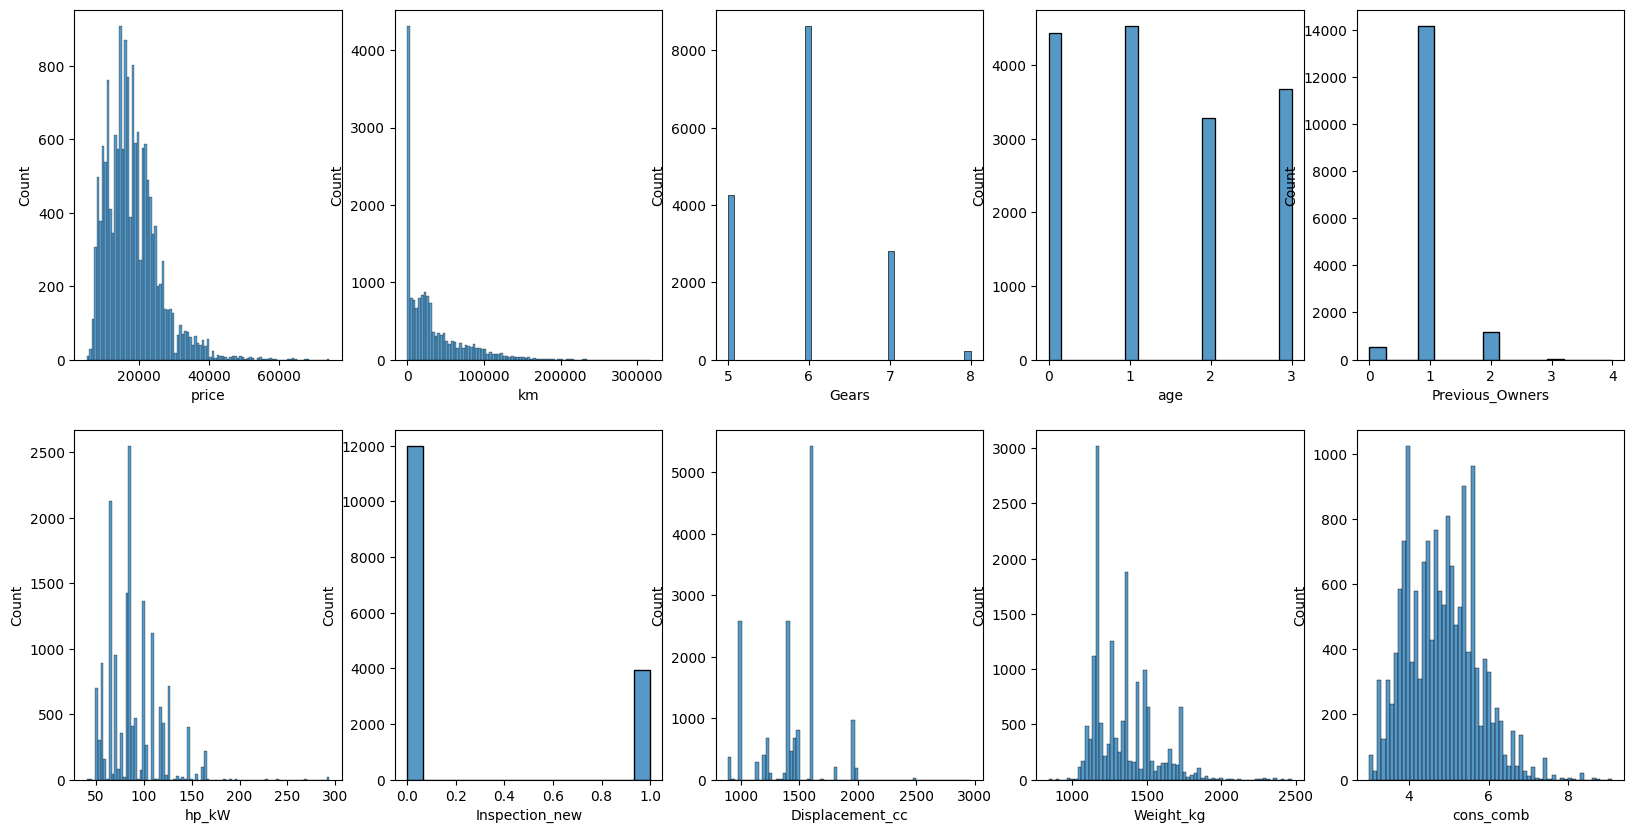

In [17]:
# Plot distribution of numerical features
plt.figure(figsize=(20,10))
for i, col in enumerate(numerical, 1):
    ax = plt.subplot(2, 5, i)
    sns.histplot(data=df, x=col, ax=ax)
plt.show()

# Without using sns:
# df[numerical].hist(bins=15, figsize=(15, 6), layout=(2, 5))
# plt.show()

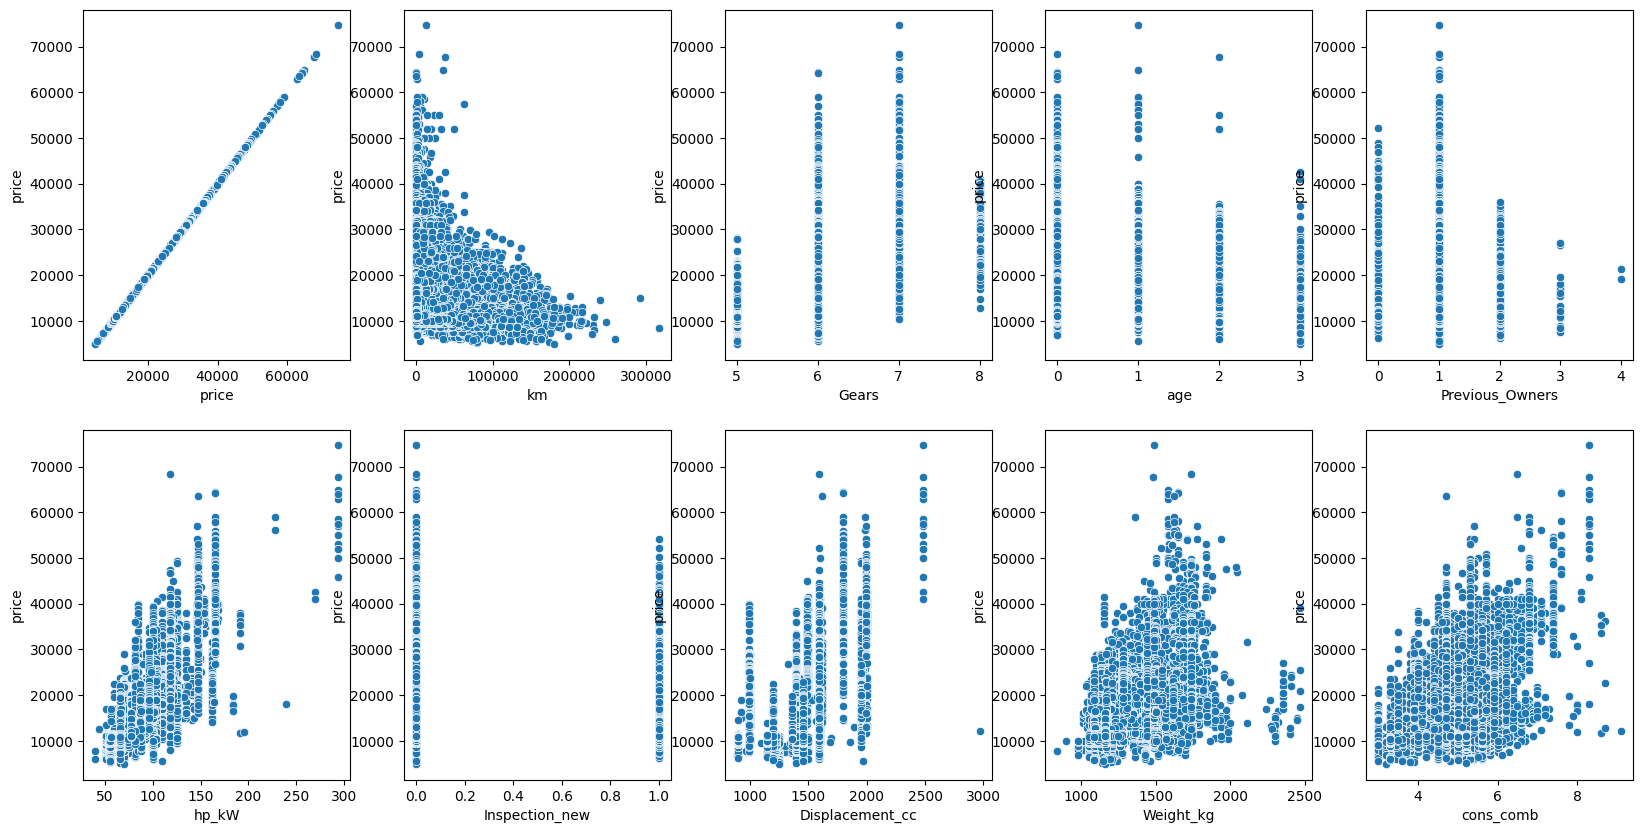

In [18]:
# Scatter plots of price against other numerical variables
plt.figure(figsize=(20,10))
for i, col in enumerate(numerical, 1):
    ax = plt.subplot(2, 5, i)
    sns.scatterplot(data=df, x=col, y='price', ax=ax)

#   without sns:
#   df.plot(kind='scatter', x=col, y='price', ax=ax)

plt.show()

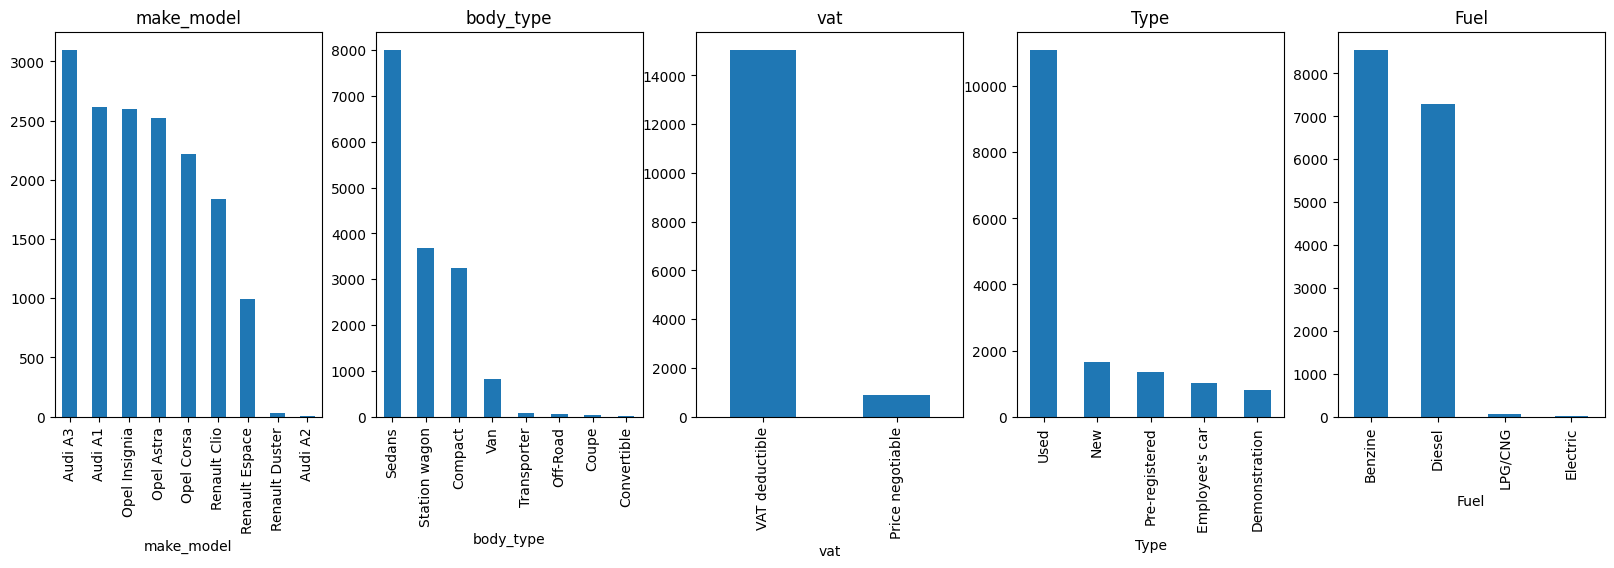

In [ ]:
# Plot distribution of selected categorical features
cols = ['make_model', 'body_type', 'vat', 'Type', 'Fuel']
plt.figure(figsize=(20, 5))
for i, col in enumerate(cols, 1):
    plt.subplot(1, 5, i)
    df[col].value_counts().plot(kind='bar')
    plt.title(col)
plt.show()

## Target Variable

In [20]:
# Distribution of target
price = df['price'].describe()
price

count    15915.000000
mean     18024.380584
std       7381.679318
min       4950.000000
25%      12850.000000
50%      16900.000000
75%      21900.000000
max      74600.000000
Name: price, dtype: float64

### Outliers

<Axes: ylabel='price'>

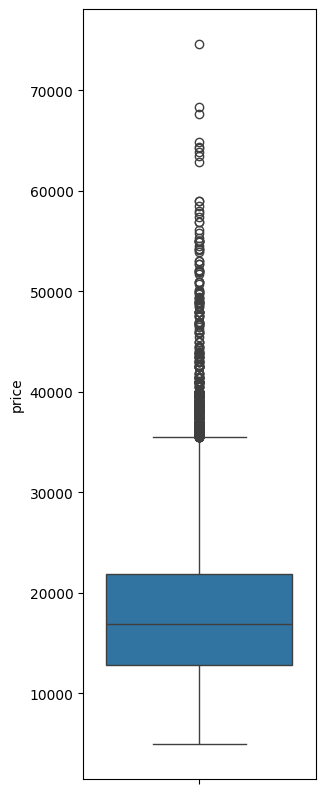

In [21]:
# Plot outliers
plt.figure(figsize=(3,10))
sns.boxplot(df['price'])

In [22]:
'''Detect and Remove Outliers using Inter Quartile Range'''
 
# Calculate the upper and lower limits

Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
print('Inter Quartile Rage: ', IQR,
      '\nLower Limit: ', lower,
      '\nUpper Linmit: ', upper)

# Create arrays of Boolean values indicating the outlier rows
upper_array = np.where(df['price'] >= upper)[0]
lower_array = np.where(df['price'] <= lower)[0]

# Removing the outliers
df.drop(index=upper_array, inplace=True)
df.drop(index=lower_array, inplace=True)


Inter Quartile Rage:  9050.0 
Lower Limit:  -725.0 
Upper Linmit:  35475.0


In [23]:
# Compare the distribution of target after removing outliers
sans_outliers = df['price'].describe()
pd.DataFrame(
    [price, sans_outliers], columns=['With Outliers', ['Without']]).T

,price,price
count,15915.000000,15435.000000
mean,18024.380584,17306.430450
std,7381.679318,6154.198465
min,4950.000000,4950.000000
25%,12850.000000,12550.000000
50%,16900.000000,16600.000000
75%,21900.000000,21490.000000
max,74600.000000,35450.000000


In [24]:
# Percentage of Outliers
float((price['count']-sans_outliers['count'])/price['count'])

0.030160226201696512

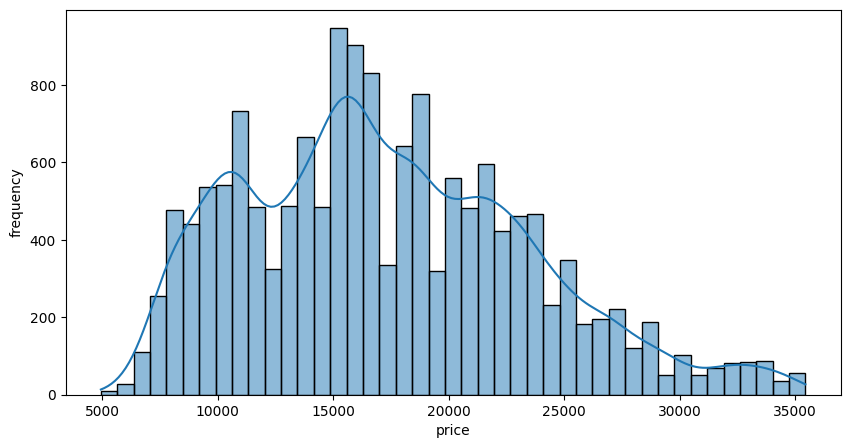

In [25]:
# Histogram of price
plt.figure(figsize=(10, 5))
sns.histplot(data=df['price'], kde=True)
plt.xlabel('price')
plt.ylabel('frequency')
plt.show()

### Skew

While symmetrical distribution will be the same on each side of the mean, skewed distribution will “pull” to one side of the mean or the other. If your data has a positive skew, it means that the majority of your data is on the left and something is pulling the distribution to the positive side, so you end up with a long leg on the right. If your data has a negative skew, it means the majority of your data is on the right with a long tail stretching in the negative direction, or left.

### Kurtosis

While skew describes how data is “pulled” to the left or right compared to the perfect symmetry of normal distribution, kurtosis describes how data may be pulled up or down, compared to the perfect bell-shape of normal distribution. Positive kurtosis pulls the distribution up into a tall, narrow shape so that the distribution curve ends up with a sharper peak at the mean. This would indicate that most of your data is more tightly clustered around the mean of your dataset (low data variance). Negative kurtosis pulls the
distribution down at the mean, so that the curve flattens out into a low, wide shape. Negative kurtosis would indicate that your data is more widely spread out from the mean of your dataset (high data variance).

In [26]:
# Skewness and Kurtosis
sk = df['price'].skew()
kt = df['price'].kurt()
print(f"Skewness: {round(sk, 3)}")
print(f"Kurtosis: {round(kt, 3)}")

Skewness: 0.482
Kurtosis: -0.234


### Normalization

Transformations are ways you can try to normalize your data, or remove a skew. To transform data, you apply a simple mathematical equation to every value in your dataset. Sometimes the transformed data will show a new distribution that removes the skew of the original data. You then can run your analyses that require normal distribution.

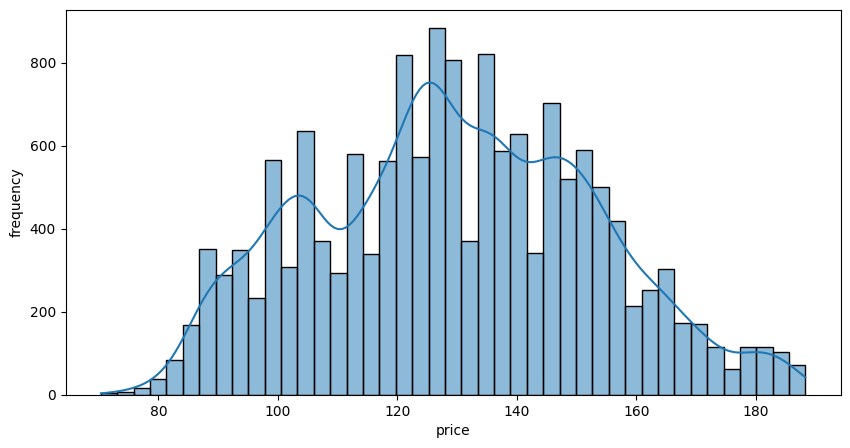

In [64]:
plt.figure(figsize=(10, 5))
sns.histplot(data=np.sqrt(df['price']), kde=True)
plt.xlabel('price')
plt.ylabel('frequency')
plt.show()

### Correlation

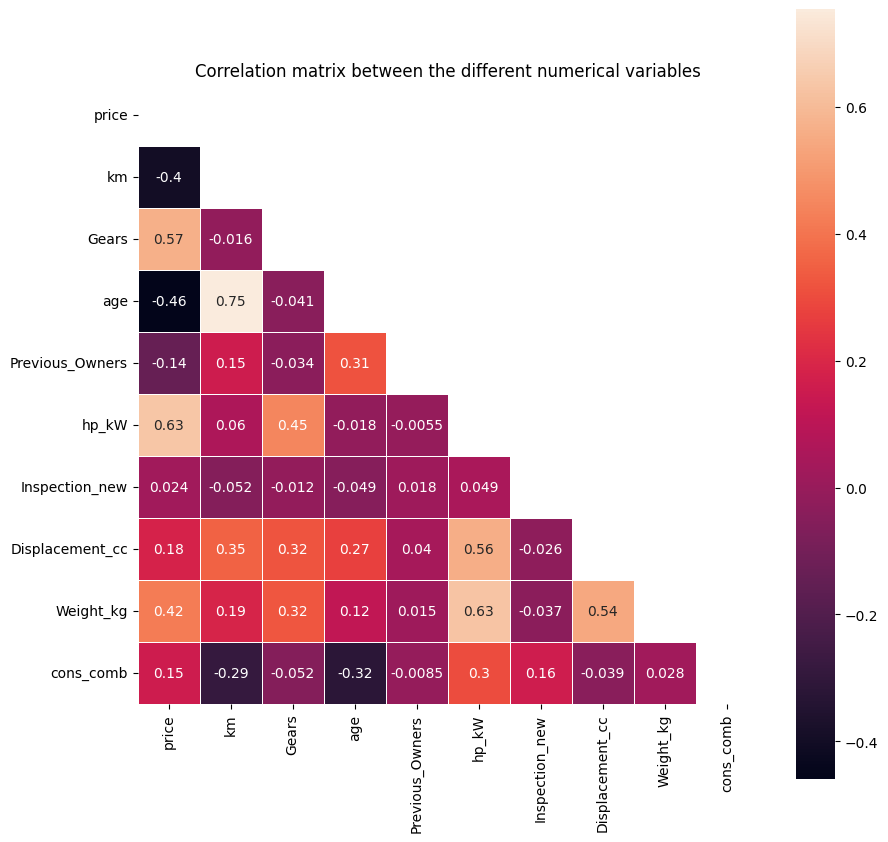

In [28]:
corr_matrix = df[numerical].corr()
mask = np.triu(corr_matrix)

plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix, 
            mask=mask, 
            linewidths=.5, 
            annot=True, 
            cbar=True, 
            square=True)
plt.title("Correlation matrix between the different numerical variables")
plt.show()

/tmp/ipykernel_93704/827125302.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


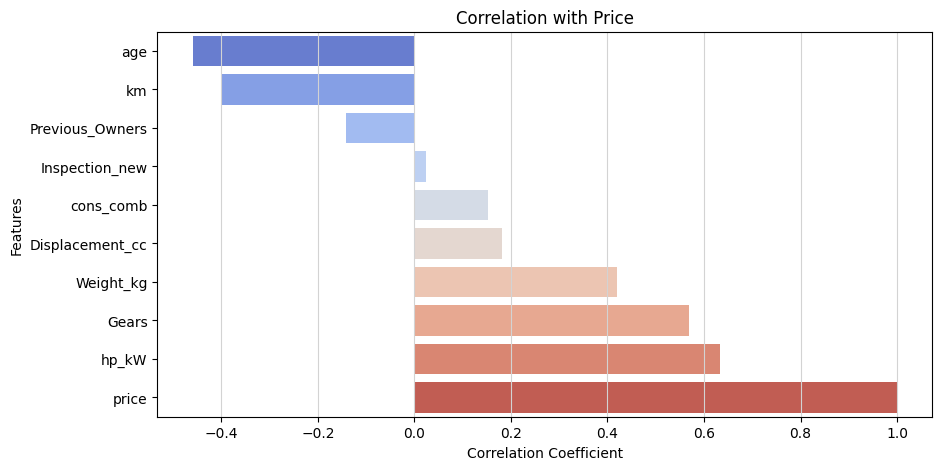

In [29]:
# Find features that may have a close linear correlation with your target variable
correlated = (df[numerical].corrwith(df['price'], axis=0)).sort_values()

# Plot the correlation of features with Loan_Status
plt.figure(figsize=(10, 5))

sns.barplot(
    y=correlated.index, 
    x=correlated.values,
    palette='coolwarm'
    )

# without sns:
# correlated.plot(
#    y=correlated.index,
#    x=correlated.values,
#    kind='barh',
#    color='skyblue'
#    )

plt.grid(axis='x', color='lightgrey')
plt.title("Correlation with Price")
plt.xlabel("Correlation Coefficient")
plt.ylabel("Features")
plt.show()